# 1. Basic Setting

In [1]:
# library setting
import pandas as pd
import numpy as np
from gensim.models import Word2Vec
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import tkinter as tk
from tkinter import messagebox
from sklearn.metrics.pairwise import cosine_similarity
import os
from datetime import datetime

In [2]:
# data loading

file_path = r'{user_path}' # user_setting
file_names = ['conditions', 'encounters', 'medications', 'observations', 'patients', 'procedures']
data = {}

for name in file_names:
    # file path generation (예: .../1. Data/patients.csv)
    full_path = os.path.join(file_path, f"{name}.csv")
    
    try:
        # data loading
        data[name] = pd.read_csv(full_path)
        print(f"✅ success: {name} (columns : {len(data[name])})")
    except FileNotFoundError:
        print(f"❌ fail: {name}.csv cannot find the file. Check the path.")
    except Exception as e:
        print(f"⚠️ error: {name} loading error: {e}")


# code-based entity generation 
patients = data.get('patients')
encounters = data.get('encounters')

# instance-based entity generation
conditions = data.get('conditions')
observations = data.get('observations')
procedures = data.get('procedures')
medications = data.get('medications')


✅ success: conditions (columns : 4023)
✅ success: encounters (columns : 8316)
✅ success: medications (columns : 5860)
✅ success: observations (columns : 86634)
✅ success: patients (columns : 117)
✅ success: procedures (columns : 20322)


# 2. Node Generation
- patient -- (has_encounter) -> encounter

- encounter -- (has_condition) -> condition (instance)
- encounter -- (has_procedure) -> procedure (instance)
- encounter -- (has_observation) -> observation (instance)
- encoutner -- (has_medication) -> medication (instance)

- procedure -- (treats) -> condition
- observation -- (evidence of) -> condition
- medication -- (treats) -> condition

- patient -- (has disease) -> condition (chronic)
- patient -- (takes) -> medication 

In [3]:
nodes = set()

# 1. Patient
for pid in patients["Id"]:
    nodes.add(("Patient", pid))


# 2. Encounter
for eid in encounters["Id"]:
    nodes.add(("Encounter", eid))


# 3. Condition
for idx, row in conditions.iterrows():
    nodes.add(("Condition", f"cond_{idx}"))


# 4. Procedure
for idx, row in procedures.iterrows():
    nodes.add(("Procedure", f"proc_{idx}"))


# 5. Observation
for idx, row in observations.iterrows():
    nodes.add(("Observation", f"obs_{idx}"))

# 6. Medication
for idx, row in medications.iterrows():
    med_id = f"med_{idx}"
    nodes.add(("Medication", med_id))

    # code node 추가
    if "CODE" in row:
        code = row["CODE"]
        nodes.add(("Medication_code", code))


# 3. Edge Generation


In [4]:
edges = []

# --- [preparation: grouping & mapping] ---
# Encounter based group
cond_group = conditions.groupby("ENCOUNTER")
proc_group = procedures.groupby("ENCOUNTER")
med_group = medications.groupby("ENCOUNTER")
obs_group = observations.groupby("ENCOUNTER")

# mapping dictionary
cond_code_map = conditions['CODE'].to_dict()
proc_code_map = procedures['CODE'].to_dict()
obs_code_map = observations['CODE'].to_dict()
med_code_map = medications['CODE'].to_dict()

# 1. patient -- (has_encounter) -> encounter

for _,row in encounters.iterrows():
    edges.append({
        'src' :('Patient',row['PATIENT']),
        'dst': ('Encounter',row['Id']),
        'relation': 'has_encounter',
        'time' : row.get('START',None),
        'CODE' : 'encounter'
    })


# 2. encounter -- (has_condition) -> condition (instance)
for idx, row in conditions.iterrows():
    cond_id = f"cond_{idx}"

    edges.append({
        "src": ("Encounter", row["ENCOUNTER"]),
        "dst": ("Condition", cond_id),
        "relation": "has_condition",
        "time": row.get("START", None),
        "CODE": row.get("CODE", "unknown")
    })

# 3. encounter -- (has_procedure) -> procedure (instance)
for idx, row in procedures.iterrows():
    proc_id = f"proc_{idx}"

    edges.append({
        "src": ("Encounter", row["ENCOUNTER"]),
        "dst": ("Procedure", proc_id),
        "relation": "has_procedure",
        "time": row.get("START", None),
        "CODE": row.get("CODE", "unknown")
    })

# 4. encounter -- (has_observation) -> observation (instance)
for idx, row in observations.iterrows():
    obs_id = f"obs_{idx}"

    edges.append({
        "src": ("Encounter", row["ENCOUNTER"]),
        "dst": ("Observation", obs_id),
        "relation": "has_observation",
        "time": row.get("DATE", None),
        "CODE": row.get("CODE", "unknown")
    })

# 5. encounter -- (has_medication) -> medication
for idx, row in medications.iterrows():
    med_id = f"med_{idx}"

    edges.append({
        "src": ("Encounter", row["ENCOUNTER"]),
        "dst": ("Medication", med_id),
        "relation": "has_medication",
        "time": row.get("START", None)
    })


cond_code_map = conditions['CODE'].to_dict()
proc_code_map = procedures['CODE'].to_dict()
obs_code_map = observations['CODE'].to_dict()
med_code_map = medications['CODE'].to_dict()


# 6. procedure -- (treats) -> condition
for enc_id in proc_group.groups:
    if enc_id in cond_group.groups:
        procs = proc_group.get_group(enc_id)
        conds = cond_group.get_group(enc_id)

        for p_idx, p_row in procs.iterrows():
            for c_idx, c_row in conds.iterrows():
                edges.append({
                    "src": ("Procedure", f"proc_{p_idx}"),
                    "dst": ("Condition", f"cond_{c_idx}"),
                    "relation": "treats",
                    "CODE": cond_code_map.get(c_idx, "unknown"),
                    "time": p_row.get("START", None) 
                })

# 7. medication -- (treats) -> condition
for enc_id in med_group.groups:
    if enc_id in cond_group.groups:
        meds = med_group.get_group(enc_id)
        conds = cond_group.get_group(enc_id)

        for m_idx, m_row in meds.iterrows():
            for c_idx, c_row in conds.iterrows():
                edges.append({
                    "src": ("Medication", f"med_{m_idx}"),
                    "dst": ("Condition", f"cond_{c_idx}"),
                    "relation": "treats",
                    "CODE": cond_code_map.get(c_idx, "unknown"),
                    "time": m_row.get("START", None)
                })

# 7-2. observation -- (evidence of) -> condition
for enc_id in obs_group.groups:
    if enc_id in cond_group.groups:
        obs_list = obs_group.get_group(enc_id)
        conds = cond_group.get_group(enc_id)

        for o_idx, o_row in obs_list.iterrows():
            for c_idx, c_row in conds.iterrows():
                edges.append({
                    "src": ("Observation", f"obs_{o_idx}"),
                    "dst": ("Condition", f"cond_{c_idx}"),
                    "relation": "evidence_of",
                    "CODE": cond_code_map.get(c_idx, "unknown"),
                    "time": o_row.get("DATE", None)
                })

# 8. patient -- (has disease) -> condition (chronic)
cond_count = conditions.groupby(["PATIENT", "CODE"]).size().reset_index(name="count")
chronic = cond_count[cond_count["count"] >= 2]
for _, row in chronic.iterrows():
    edges.append({
        "src": ("Patient", row["PATIENT"]),
        "dst": ("Condition_code", row["CODE"]),  
        "relation": "has_disease",
        "CODE": row["CODE"],
        "time": None 
    })

# 9. patient -- (takes) -> medication
med_count = medications.groupby(["PATIENT", "CODE"]).size().reset_index(name="count")
for _, row in med_count[med_count["count"] >= 2].iterrows():
    edges.append({
        "src": ("Patient", row["PATIENT"]),
        "dst": ("Medication_code", row["CODE"]),
        "relation": "takes_regularly",
        "CODE": row["CODE"],
        "time": None
    })


# 4. Graph Generation

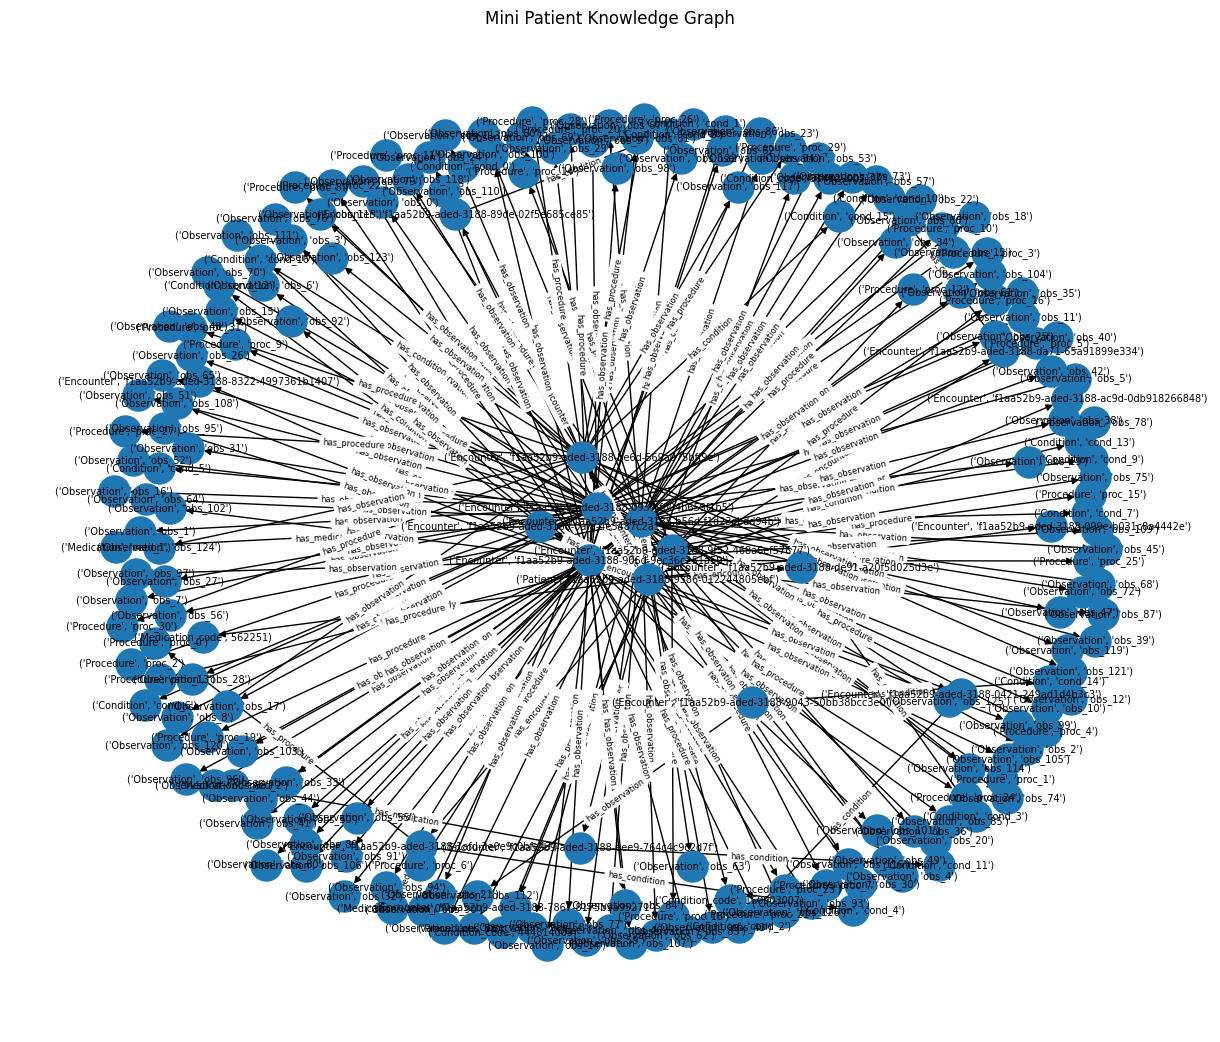

In [5]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

# node & egde generation
for edge in edges:
    src = edge["src"]
    dst = edge["dst"]
    rel = edge["relation"]

    G.add_node(src)
    G.add_node(dst)
    G.add_edge(src, dst, label=rel)

# visualization partly 
sub_edges = list(G.edges(data=True))[:200]

H = nx.DiGraph()
for u, v, d in sub_edges:
    H.add_edge(u, v, label=d["label"])

plt.figure(figsize=(12, 10))
pos = nx.spring_layout(H, k=0.5)

nx.draw(H, pos, with_labels=True, node_size=500, font_size=7)

edge_labels = {(u, v): d["label"] for u, v, d in H.edges(data=True)}
nx.draw_networkx_edge_labels(H, pos, edge_labels=edge_labels, font_size=6)

plt.title("Mini Patient Knowledge Graph")
plt.show()

# 5. Input (specific patient id ) -> Output : Target Patient Knowledge Graph

In [6]:
import networkx as nx
import matplotlib.pyplot as plt


def visualize_patient_kg(edges, patient_id, max_edges=50):
    """
    a fuction to visualize a certain patient

    edges: edge list
    patient_id: target patient
    max_edges: prvention from being too large
    """

    # -----------------------------
    # 1. patient → encounter search
    # -----------------------------
    patient_encounters = set(
        e["dst"][1]
        for e in edges
        if e["src"] == ("Patient", patient_id)
        and e["relation"] == "has_encounter"
    )

    # -----------------------------
    # 2. 1-hop filtering
    # -----------------------------
    filtered_edges = []

    for e in edges:
        src_type, src_id = e["src"]
        dst_type, dst_id = e["dst"]

        if (
            src_id == patient_id
            or dst_id == patient_id
            or src_id in patient_encounters
            or dst_id in patient_encounters
        ):
            filtered_edges.append(e)

    # -----------------------------
    # 3. 2-hop enlargement
    # -----------------------------
    node_ids = set()
    for e in filtered_edges:
        node_ids.add(e["src"][1])
        node_ids.add(e["dst"][1])

    for e in edges:
        if (
            e["src"][1] in node_ids
            or e["dst"][1] in node_ids
        ):
            filtered_edges.append(e)

    # removal duplicates
    filtered_edges = list({(e["src"], e["dst"], e["relation"]) : e for e in filtered_edges}.values())

    # limitation if it's too large
    filtered_edges = filtered_edges[:max_edges]

    # -----------------------------
    # 4. graph generation
    # -----------------------------
    G = nx.DiGraph()

    for e in filtered_edges:
        src = e["src"]
        dst = e["dst"]
        rel = e["relation"]

        G.add_node(src)
        G.add_node(dst)
        G.add_edge(src, dst, label=rel)

    # -----------------------------
    # 5. color match
    # -----------------------------
    def get_color(node):
        if node[0] == "Patient":
            return "red"
        elif node[0] == "Encounter":
            return "orange"
        elif node[0] == "Condition":
            return "blue"
        elif node[0] == "Procedure":
            return "green"
        elif node[0] == "Observation":
            return "purple"
        elif node[0] == "Condition_code":
            return "black"
        elif node[0] == 'Medication':
            return 'yellow'
        else:
            return "gray"

    node_colors = [get_color(n) for n in G.nodes()]

        # -----------------------------
    # 6. visualization (clean version)
    # -----------------------------
    import math

    plt.figure(figsize=(12, 10))

    # -----------------------------
    # center node
    # -----------------------------
    center_node = ("Patient", patient_id)

    # -----------------------------
    # level division
    # -----------------------------
    level_0 = [center_node]

    level_1 = [n for n in G.nodes() if n[0] == "Encounter"]
    level_2 = [
        n for n in G.nodes()
        if n[0] in ["Condition", "Procedure", "Observation", "Condition_code",'Medication']
        ]

    
    pos = {}
    
    # fallback
    for node in G.nodes():
        if node not in pos:
            pos[node] = (0, 0)


    # -----------------------------
    # Patient (center)
    # -----------------------------
    pos[center_node] = (0, 0)

    # -----------------------------
    # Encounter (1-ring)
    # -----------------------------
    for i, node in enumerate(level_1):
        angle = 2 * math.pi * i / len(level_1) if len(level_1) > 0 else 0
        pos[node] = (2 * math.cos(angle), 2 * math.sin(angle))

    # -----------------------------
    # Clinical nodes (2-ring)
    # -----------------------------
    for i, node in enumerate(level_2):
        angle = 2 * math.pi * i / len(level_2) if len(level_2) > 0 else 0
        pos[node] = (4 * math.cos(angle), 4 * math.sin(angle))

    # -----------------------------
    # label organization
    # -----------------------------
    labels = {n: f"{n[0]}\n{n[1]}" for n in G.nodes()}

    # -----------------------------
    # graph generation
    # -----------------------------
    nx.draw(
        G,
        pos,
        labels=labels,
        node_color=node_colors,
        node_size=900,
        font_size=7
    )

    edge_labels = {(u, v): d["label"] for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)

    plt.title(f"Patient {patient_id} Knowledge Graph", fontsize=14)
    plt.axis("off")
    plt.show()

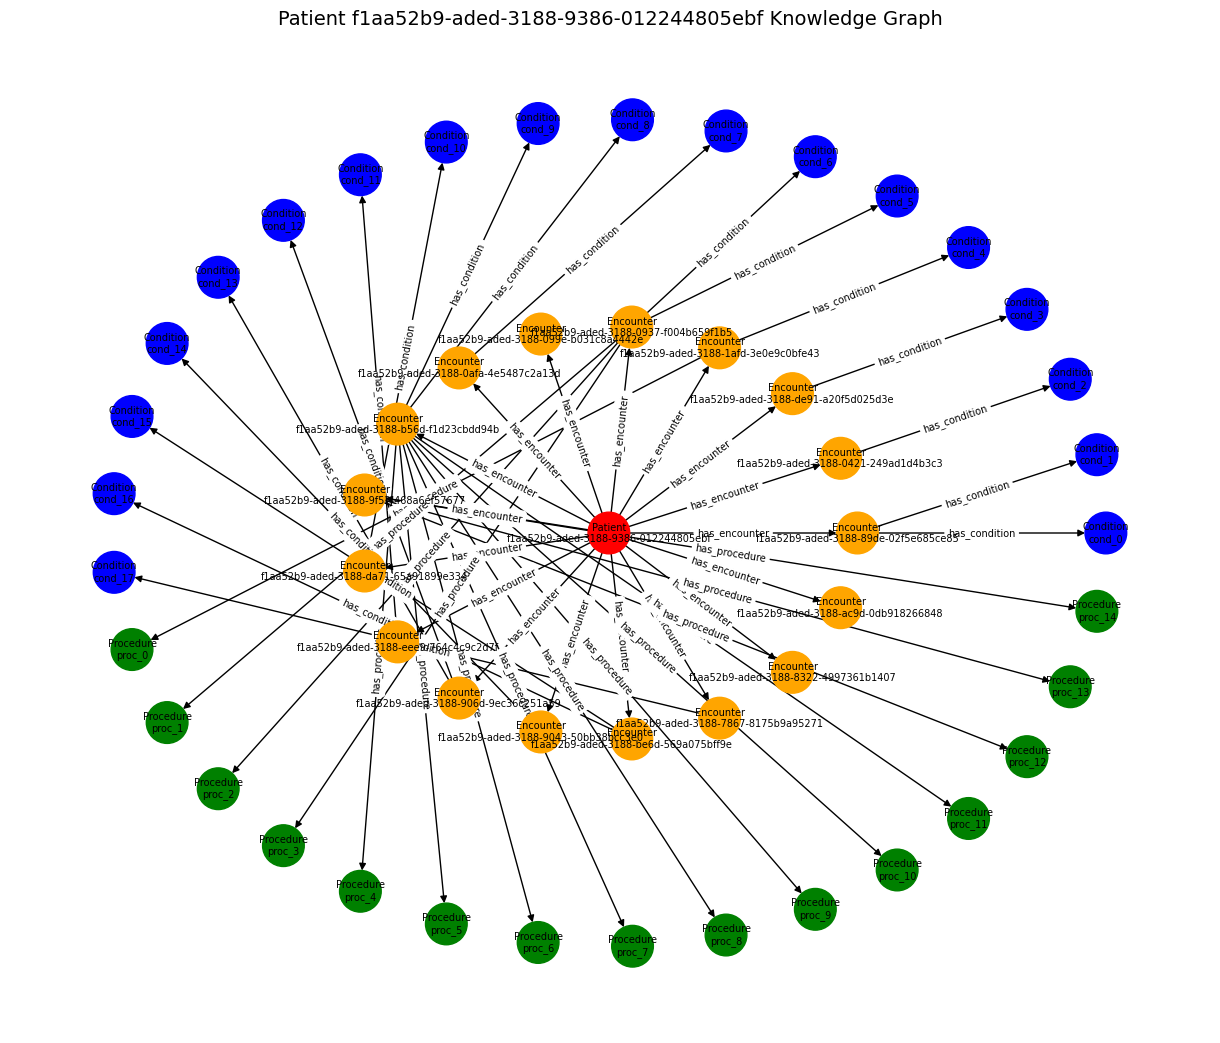

In [7]:
# a fuction when it's click 
def run_visualization():
    patient_id = entry.get().strip()

    if not patient_id:
        messagebox.showwarning("Input Error", "환자 ID를 입력해주세요.")
        return

    try:
        visualize_patient_kg(edges, patient_id)
    except Exception as e:
        messagebox.showerror("Error", f"그래프 생성 중 오류 발생:\n{e}")


# -----------------------------
# UI generation
# -----------------------------
root = tk.Tk()
root.title("Patient Knowledge Graph Viewer")
root.geometry("400x150")

# label
label = tk.Label(root, text="환자 ID 입력", font=("Arial", 12))
label.pack(pady=10)

# input UI
entry = tk.Entry(root, width=20, font=("Arial", 12))
entry.pack(pady=5)

# button
button = tk.Button(root, text="그래프 보기", command=run_visualization)
button.pack(pady=10)

# execution
root.mainloop()

# 6. Sequence-Based Trajectory Embedding Vector Generation

In [8]:
# 1. trajectory generation (time + token)

def build_patient_trajectory(edges, patient_id):

    events = []

    # time standard
    times = [parse_time(e["time"]) for e in edges if e.get("time")]
    first_time = min(times) if times else None

    # patient → encounter
    patient_encounters = set(
        e["dst"][1]
        for e in edges
        if (
            e["src"][0] == "Patient"
            and e["src"][1] == patient_id
            and e["relation"] == "has_encounter"
        )
    )

    for e in edges:
        src_type, src_id = e["src"]
        dst_type, dst_id = e["dst"]

        if (
            src_id == patient_id
            or dst_id == patient_id
            or src_id in patient_encounters
            or dst_id in patient_encounters
        ):

            if e.get("time"):
                t = parse_time(e["time"])
                token = make_token(e, first_time)
                events.append((t, token))

    events.sort(key=lambda x: x[0])

    return events


# 2. token generation (relation + node + time bucket)
def parse_time(t):
    if t is None or pd.isna(t): return None
    if isinstance(t, datetime): return t
    for fmt in ("%Y-%m-%dT%H:%M:%SZ", "%Y-%m-%d"):
        try: return datetime.strptime(t, fmt)
        except: continue
    return None

def make_token(e, first_time):
    dst_type, _ = e["dst"]
    rel = e["relation"]
    # medical code into instance_id
    code = e.get("CODE", "unknown") 
    
    time_val = e.get("time")
    if time_val and first_time:
        t = parse_time(time_val)
        delta = (t - first_time).days
        if delta < 30: t_bucket = "early"
        elif delta < 180: t_bucket = "mid"
        else: t_bucket = "late"
    else:
        t_bucket = "unk"

    # token structure : relation_type_code_timestamp
    return f"{rel}_{dst_type}_{code}_{t_bucket}"


# 3. gap token (relative time)
def add_time_gap(events):

    sequence = []

    for i in range(len(events)):
        time, token = events[i]
        sequence.append(token)

        # interval between next events
        if i < len(events) - 1:
            next_time = events[i + 1][0]

            if time and next_time:
                gap = (next_time - time).days

                if gap < 7:
                    gap_token = "gap_short"
                elif gap < 30:
                    gap_token = "gap_mid"
                else:
                    gap_token = "gap_long"

                sequence.append(gap_token)

    return sequence


# 4. Word2Vec learning
def train_embedding(all_sequences, vector_size=64):

    model = Word2Vec(
        sentences=all_sequences,
        vector_size=vector_size,
        window=5,
        min_count=1,
        workers=4
    )

    return model


# 5. patient embedding generation
def get_patient_embedding(sequence, model):

    vectors = []
    seq_len = len(sequence)

    for i, token in enumerate(sequence):
        if token in model.wv:
            weight = (i + 1) / seq_len  # emphasizing recent event
            vectors.append(model.wv[token] * weight)

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    # mean pooling (baseline)
    return np.mean(vectors, axis=0)

# 7. Similar Patients Search

In [9]:
# 1. whole patients embedding generation 

def build_all_patient_embeddings(edges, model):

    patient_ids = set()

    # patient id collection
    for e in edges:
        if e["src"][0] == "Patient":
            patient_ids.add(e["src"][1])
        if e["dst"][0] == "Patient":
            patient_ids.add(e["dst"][1])

    patient_embeddings = {}

    for pid in patient_ids:

        # 1. trajectory
        events = build_patient_trajectory(edges, pid)

        # 2. sequence 
        sequence = add_time_gap(events)

        # 3. embedding
        emb = get_patient_embedding(sequence, model)
        patient_embeddings[pid] = emb

    return patient_embeddings

# 2. Similarity matrix 

def compute_similarity_matrix(patient_embeddings):
    patient_ids = list(patient_embeddings.keys())
    vectors = np.array(list(patient_embeddings.values()))
    sim_matrix = cosine_similarity(vectors)
    return patient_ids, sim_matrix

# 3. Similar patient search
def find_similar_patients(target_id, patient_ids, sim_matrix, top_k=5):
    idx = patient_ids.index(target_id)
    scores = sim_matrix[idx]
    pairs = list(zip(patient_ids, scores))
    pairs = [p for p in pairs if p[0] != target_id]
    pairs.sort(key=lambda x: x[1], reverse=True)

    return pairs[:top_k]

In [10]:
# 1. whole patients sequence generation 

def build_all_sequences(edges):

    patient_ids = set()

    for e in edges:
        if e["src"][0] == "Patient":
            patient_ids.add(e["src"][1])
        if e["dst"][0] == "Patient":
            patient_ids.add(e["dst"][1])

    all_sequences = []

    for pid in patient_ids:
        events = build_patient_trajectory(edges, pid)
        sequence = add_time_gap(events)

        if len(sequence) > 0:
            all_sequences.append(sequence)

    return all_sequences

# 2. Word2Vect model learning
all_sequences = build_all_sequences(edges)

model = Word2Vec(
    sentences=all_sequences,
    vector_size=64,
    window=5,
    min_count=1,
    workers=4
)

# 3. patient embedding generation
patient_embeddings = build_all_patient_embeddings(edges, model)

# 4. similarity matrix generation
patient_ids, sim_matrix = compute_similarity_matrix(patient_embeddings)

# 5. target patient similarity 
target_patient = input('Put your target id')
similar = find_similar_patients(target_patient, patient_ids, sim_matrix)
print(f"\n[Patient {target_patient} - Top Similar Patients]\n")

for pid, score in similar:
    print(f"{pid} -> similarity :{score:.4f}")

ValueError: '' is not in list

In [ ]:
patient_embeddings.to_csv(r'patients_embeddings.csv')

# 8. Visualization with t-SNE

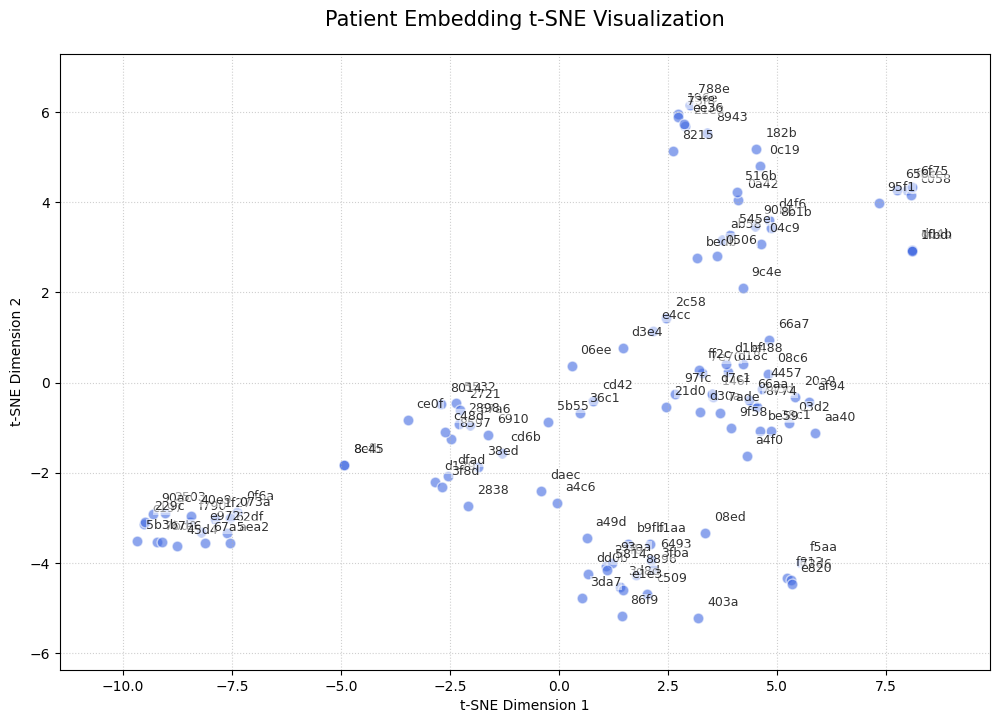

In [ ]:
patient_ids = list(patient_embeddings.keys())
X = np.array(list(patient_embeddings.values()))

# t-SNE transformation
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_2d = tsne.fit_transform(X)

plt.figure(figsize=(12, 8))

# 1. scatter_plot 
plt.scatter(X_2d[:, 0], X_2d[:, 1], c='royalblue', edgecolors='white', s=60, alpha=0.6, label='Patients')

# 2. text arrangement
for i, pid in enumerate(patient_ids):

    plt.text(X_2d[i, 0] + 0.2, X_2d[i, 1] + 0.2, 
             pid[:4], # ID : 4number (in front)
             fontsize=9, 
             ha='left', 
             va='bottom',
             alpha=0.8,
             bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', pad=0.1)) # 글자 뒤에 살짝 배경색을 넣어 가독성 높임

plt.title('Patient Embedding t-SNE Visualization', fontsize=15, pad=20)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True, linestyle=':', alpha=0.6)

plt.margins(0.1)

plt.show()